# Visualisation de la cascade wavelet

Ce notebook est adapté aux sorties de `wave_cascade_generator.py`.

Objectif de la cascade :

```text
cA3
-> diffusion j3 -> [cH3, cV3, cD3]
-> IDWT -> cA2
-> diffusion j2 -> [cH2, cV2, cD2]
-> IDWT -> cA1
-> diffusion j1 -> [cH1, cV1, cD1]
-> IDWT -> image finale
```

Le notebook :

1. recharge les coefficients réels `j3`, `j2`, `j1` ;
2. recharge les sorties de la cascade générée ;
3. compare les coefficients à chaque niveau ;
4. compare les approximations reconstruites intermédiaires (`cA2`, `cA1`) ;
5. compare les **images finales** ;
6. calcule le **FID / PhyFID uniquement sur l'image finale**.


---
## Imports et utilitaires

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
import pywt


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "wave_diffusion.py").exists() and (candidate / "lib").exists():
            return candidate
    raise RuntimeError("Impossible de trouver la racine du projet RT-Diffusion.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DEVICE =", DEVICE)


PROJECT_ROOT = /home/chapuissamuel/Documents/code/RT-Diffusion
DEVICE = cpu


In [2]:
def load_pt_dataset(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def ensure_tensor(x):
    return x if torch.is_tensor(x) else torch.as_tensor(x)


def squeeze_channel(images):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        return images[:, 0]
    return images


def print_dataset_summary(name, images):
    tensor = ensure_tensor(images).float()
    print(
        f"{name:<28} shape={tuple(tensor.shape)!s:<18} dtype={tensor.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, title=None, colorbar=False):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        images = images[:, 0]

    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy()
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    plt.show()


def reconstruct_wavelet_sample(coeffs, wavelet="db1", mode="periodization"):
    coeffs = ensure_tensor(coeffs).detach().cpu().numpy()
    cA = coeffs[0]
    cH = coeffs[1]
    cV = coeffs[2]
    cD = coeffs[3]
    return pywt.idwt2((cA, (cH, cV, cD)), wavelet=wavelet, mode=mode)


def reconstruct_all_wavelet_samples(coeffs_array, wavelet="db1", mode="periodization"):
    coeffs_array = ensure_tensor(coeffs_array)
    return np.stack([
        reconstruct_wavelet_sample(coeffs, wavelet=wavelet, mode=mode)
        for coeffs in coeffs_array
    ], axis=0)


def to_numpy_images(images):
    images = squeeze_channel(images)
    return ensure_tensor(images).detach().cpu().numpy().astype(np.float32)


---
## Configuration

In [7]:
CASCADE_LEVELS = [3, 2, 1]
DATASET = "validation"  # training / validation / test

DATA_ROOT = PROJECT_ROOT / "data" / "RT64" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "generated" / "cascade"
WAVELET = "db1"
BORDER_MODE = "periodization"
N_SAMPLES = 8
SEED = 0

REAL_COEFF_PATHS = {
    level: DATA_ROOT / f"j{level}_{DATASET}.pt"
    for level in CASCADE_LEVELS
}

GENERATED_COEFF_PATHS = {
    3: OUTPUT_DIR / "j3_generated_coefficients.pt",
    2: OUTPUT_DIR / "j2_generated_coefficients.pt",
    1: OUTPUT_DIR / "j1_generated_coefficients.pt",
}

RECONSTRUCTED_CA_PATHS = {
    2: OUTPUT_DIR / "j2_reconstructed_cA.pt",
    1: OUTPUT_DIR / "j1_reconstructed_cA.pt",
}

FINAL_GENERATED_IMAGES_PT = OUTPUT_DIR / "generated_images.pt"

PHYFID_ENCODER = PROJECT_ROOT / "outputs" / "phyFID" / "64phyfid_encoder.pt"
PHYFID_BATCH_SIZE = 128


---
## Chargement des données de la cascade

In [9]:
real_coeffs = {level: load_pt_dataset(path) for level, path in REAL_COEFF_PATHS.items()}
generated_coeffs = {level: load_pt_dataset(path) for level, path in GENERATED_COEFF_PATHS.items()}
reconstructed_ca = {level: load_pt_dataset(path) for level, path in RECONSTRUCTED_CA_PATHS.items()}
final_generated_images = load_pt_dataset(FINAL_GENERATED_IMAGES_PT)

final_real_images = reconstruct_all_wavelet_samples(
    real_coeffs[1],
    wavelet=WAVELET,
    mode=BORDER_MODE,
)

for level in CASCADE_LEVELS:
    print_dataset_summary(f"real coeffs j{level}", real_coeffs[level])
    print_dataset_summary(f"generated coeffs j{level}", generated_coeffs[level])

print_dataset_summary("reconstructed cA2", reconstructed_ca[2])
print_dataset_summary("reconstructed cA1", reconstructed_ca[1])
print_dataset_summary("final real images", final_real_images)
print_dataset_summary("final generated images", final_generated_images)


real coeffs j3               shape=(6528, 4, 8, 8)    dtype=torch.float32 min=  -3.630 max=   8.000 mean=   1.053 std=   2.496
generated coeffs j3          shape=(64, 4, 8, 8)      dtype=torch.float32 min=  -2.920 max=   8.000 mean=   1.048 std=   2.494
real coeffs j2               shape=(6528, 4, 16, 16)  dtype=torch.float32 min=  -1.748 max=   4.000 mean=   0.513 std=   1.270
generated coeffs j2          shape=(64, 4, 16, 16)    dtype=torch.float32 min=  -1.194 max=   4.306 mean=   0.513 std=   1.259
real coeffs j1               shape=(6528, 4, 32, 32)  dtype=torch.float32 min=  -0.805 max=   2.000 mean=   0.253 std=   0.640
generated coeffs j1          shape=(64, 4, 32, 32)    dtype=torch.float32 min=  -0.441 max=   2.267 mean=   0.252 std=   0.632
reconstructed cA2            shape=(64, 1, 16, 16)    dtype=torch.float32 min=  -0.403 max=   4.306 mean=   1.989 std=   1.833
reconstructed cA1            shape=(64, 1, 32, 32)    dtype=torch.float32 min=  -0.349 max=   2.267 mean=   0.9

---
## Fonctions de visualisation

In [10]:
def plot_wavelet_level_comparison(real_data,
                                  generated_data,
                                  level,
                                  n_examples=3,
                                  seed=0,
                                  channel_titles=None,
                                  cmap="gray"):
    real_data = ensure_tensor(real_data)
    generated_data = ensure_tensor(generated_data)

    n_examples = min(n_examples, len(real_data), len(generated_data))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_data), len(generated_data)), size=n_examples, replace=False)

    if channel_titles is None:
        channel_titles = ["Approximation cA", "Horizontal cH", "Vertical cV", "Diagonal cD"]

    fig, axes = plt.subplots(4, 2 * n_examples, figsize=(4 * n_examples, 8))

    for example, idx in enumerate(indices):
        real_coeff = real_data[idx]
        gen_coeff = generated_data[idx]
        c0 = example * 2

        axes[0, c0].imshow(real_coeff[0], cmap=cmap)
        axes[0, c0].set_title(f"Ref j{level}\n{channel_titles[0]}")
        axes[0, c0 + 1].imshow(gen_coeff[0], cmap=cmap)
        axes[0, c0 + 1].set_title(f"Gen j{level}\n{channel_titles[0]}")

        axes[1, c0].imshow(real_coeff[1], cmap=cmap)
        axes[1, c0].set_title(channel_titles[1])
        axes[1, c0 + 1].imshow(gen_coeff[1], cmap=cmap)
        axes[1, c0 + 1].set_title(channel_titles[1])

        axes[2, c0].imshow(real_coeff[2], cmap=cmap)
        axes[2, c0].set_title(channel_titles[2])
        axes[2, c0 + 1].imshow(gen_coeff[2], cmap=cmap)
        axes[2, c0 + 1].set_title(channel_titles[2])

        axes[3, c0].imshow(real_coeff[3], cmap=cmap)
        axes[3, c0].set_title(channel_titles[3])
        axes[3, c0 + 1].imshow(gen_coeff[3], cmap=cmap)
        axes[3, c0 + 1].set_title(channel_titles[3])

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()


def plot_single_channel_comparison(real_images,
                                   generated_images,
                                   title,
                                   n_examples=6,
                                   seed=0,
                                   cmap="gray"):
    real_images = squeeze_channel(real_images)
    generated_images = squeeze_channel(generated_images)

    n_examples = min(n_examples, len(real_images), len(generated_images))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_images), len(generated_images)), size=n_examples, replace=False)

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 3 * n_examples))
    if n_examples == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        ref = ensure_tensor(real_images[idx]).detach().cpu().numpy()
        gen = ensure_tensor(generated_images[idx]).detach().cpu().numpy()
        err = np.abs(ref - gen)

        vmin = min(ref.min(), gen.min())
        vmax = max(ref.max(), gen.max())

        axes[row, 0].imshow(ref, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"Reference\nidx={idx}")

        axes[row, 1].imshow(gen, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"Generated\nidx={idx}")

        axes[row, 2].imshow(err, cmap="magma")
        axes[row, 2].set_title(f"|Error|\nMAE={err.mean():.3e}")

        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


---
## Comparaison des coefficients générés à chaque niveau

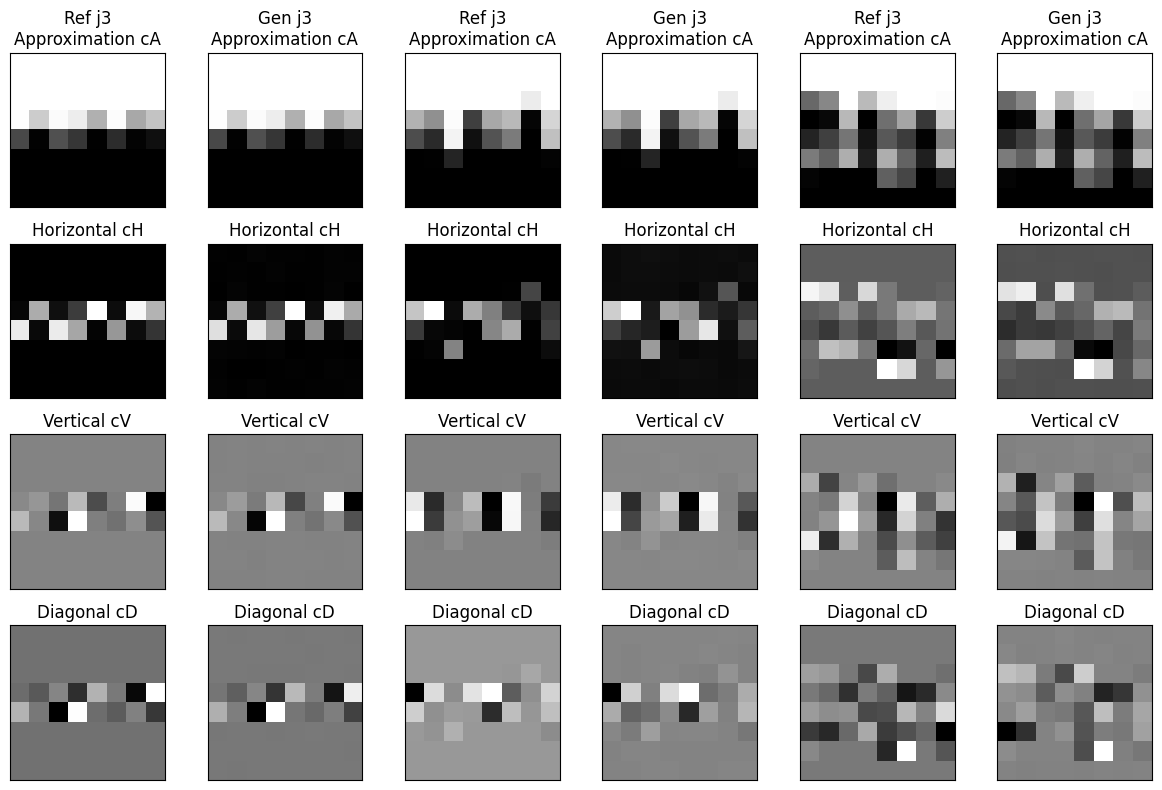

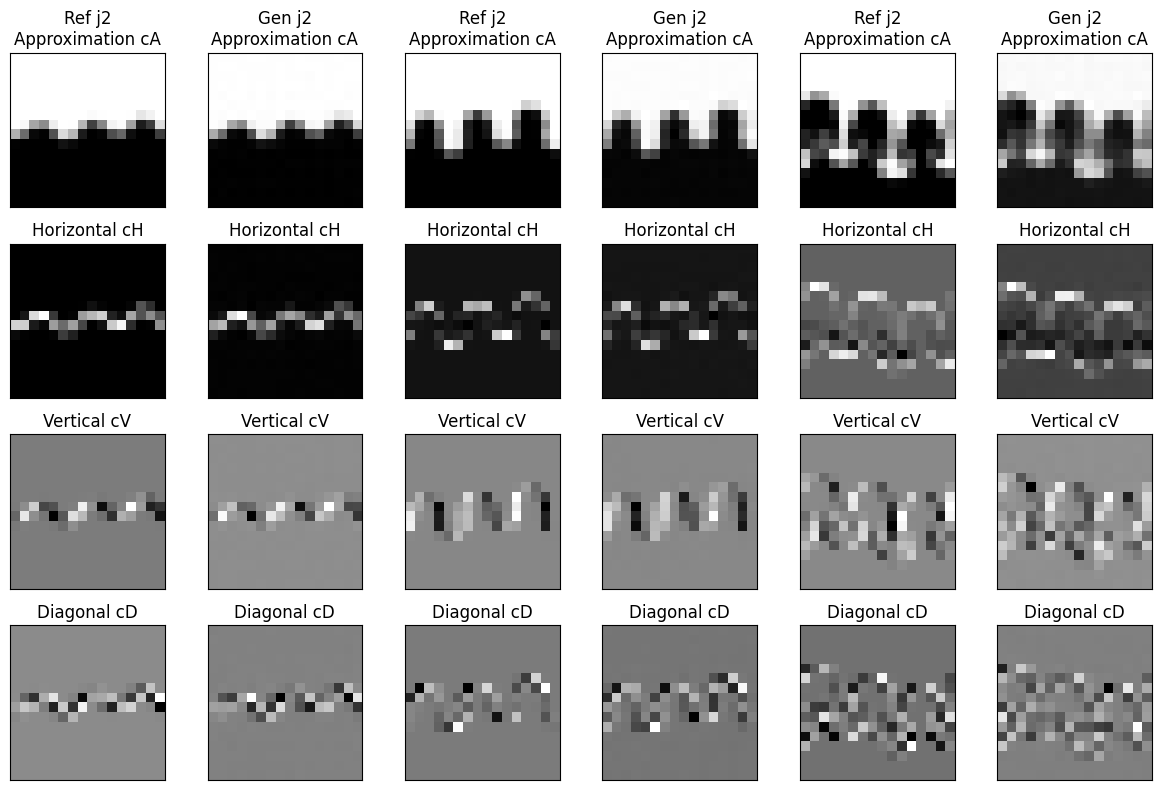

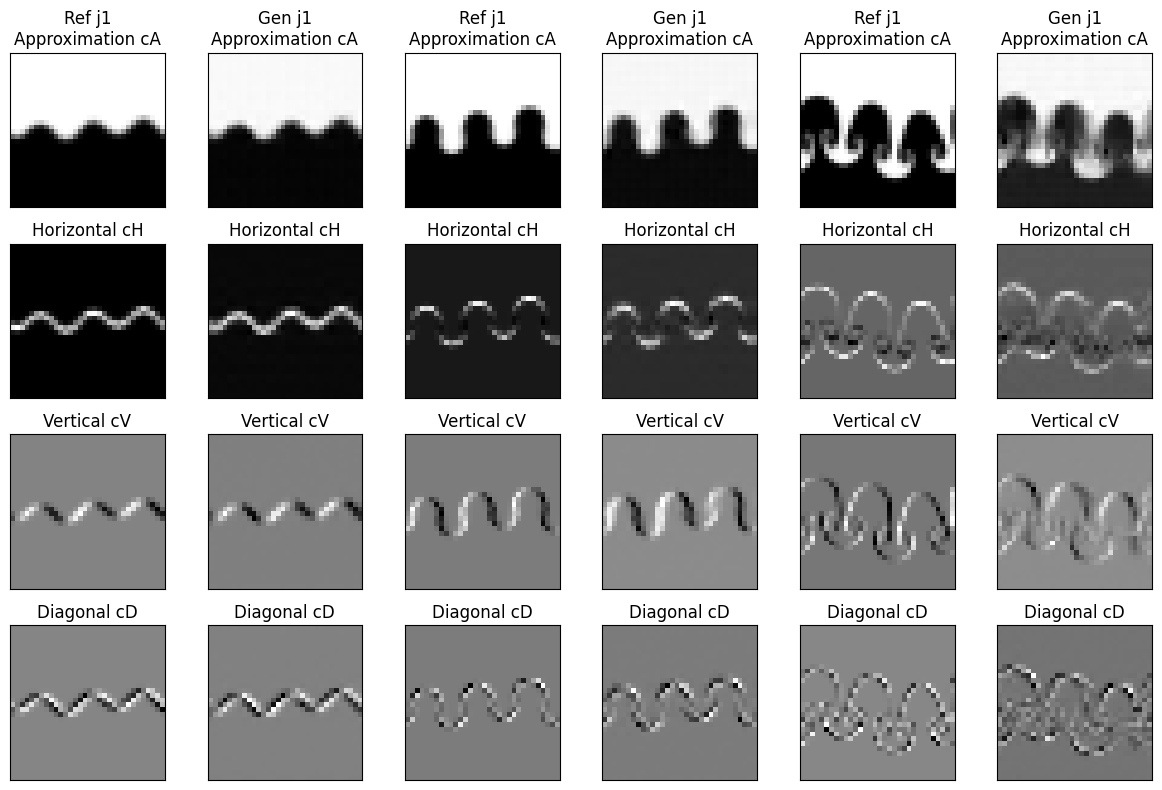

In [11]:
for level in CASCADE_LEVELS:
    plot_wavelet_level_comparison(
        real_coeffs[level],
        generated_coeffs[level],
        level=level,
        n_examples=3,
        seed=SEED,
        cmap="gray",
    )


---
## Comparaison des approximations intermédiaires reconstruites

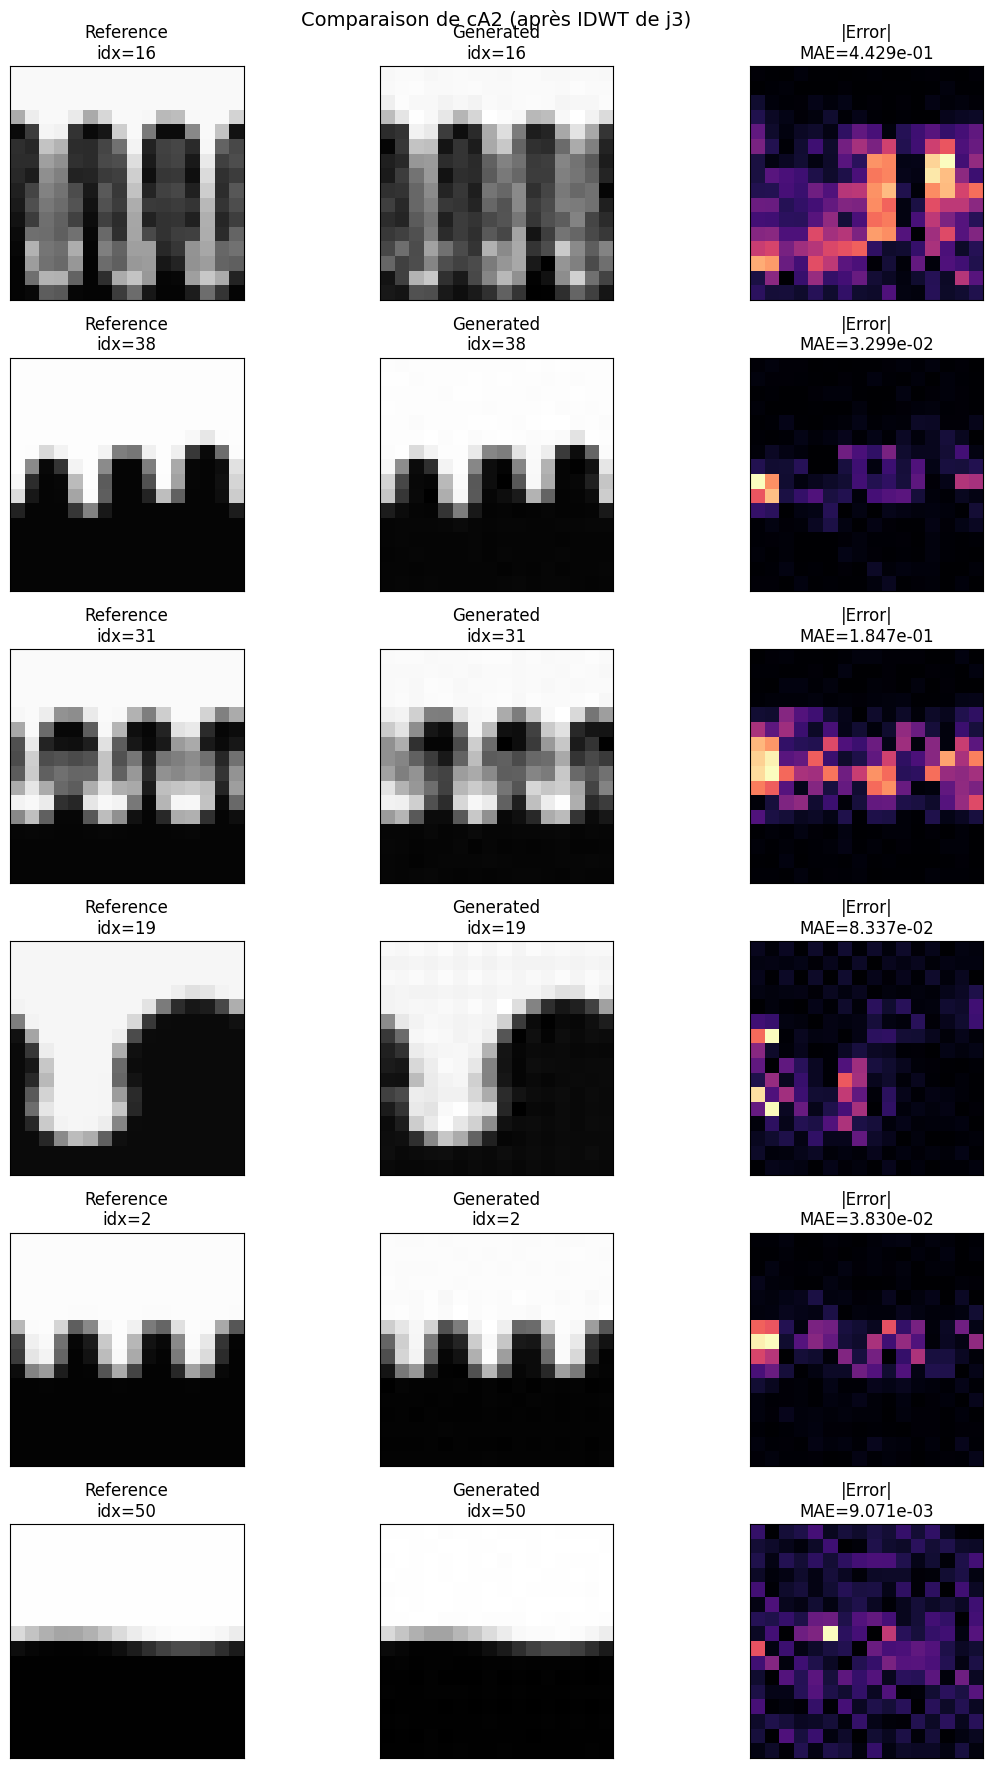

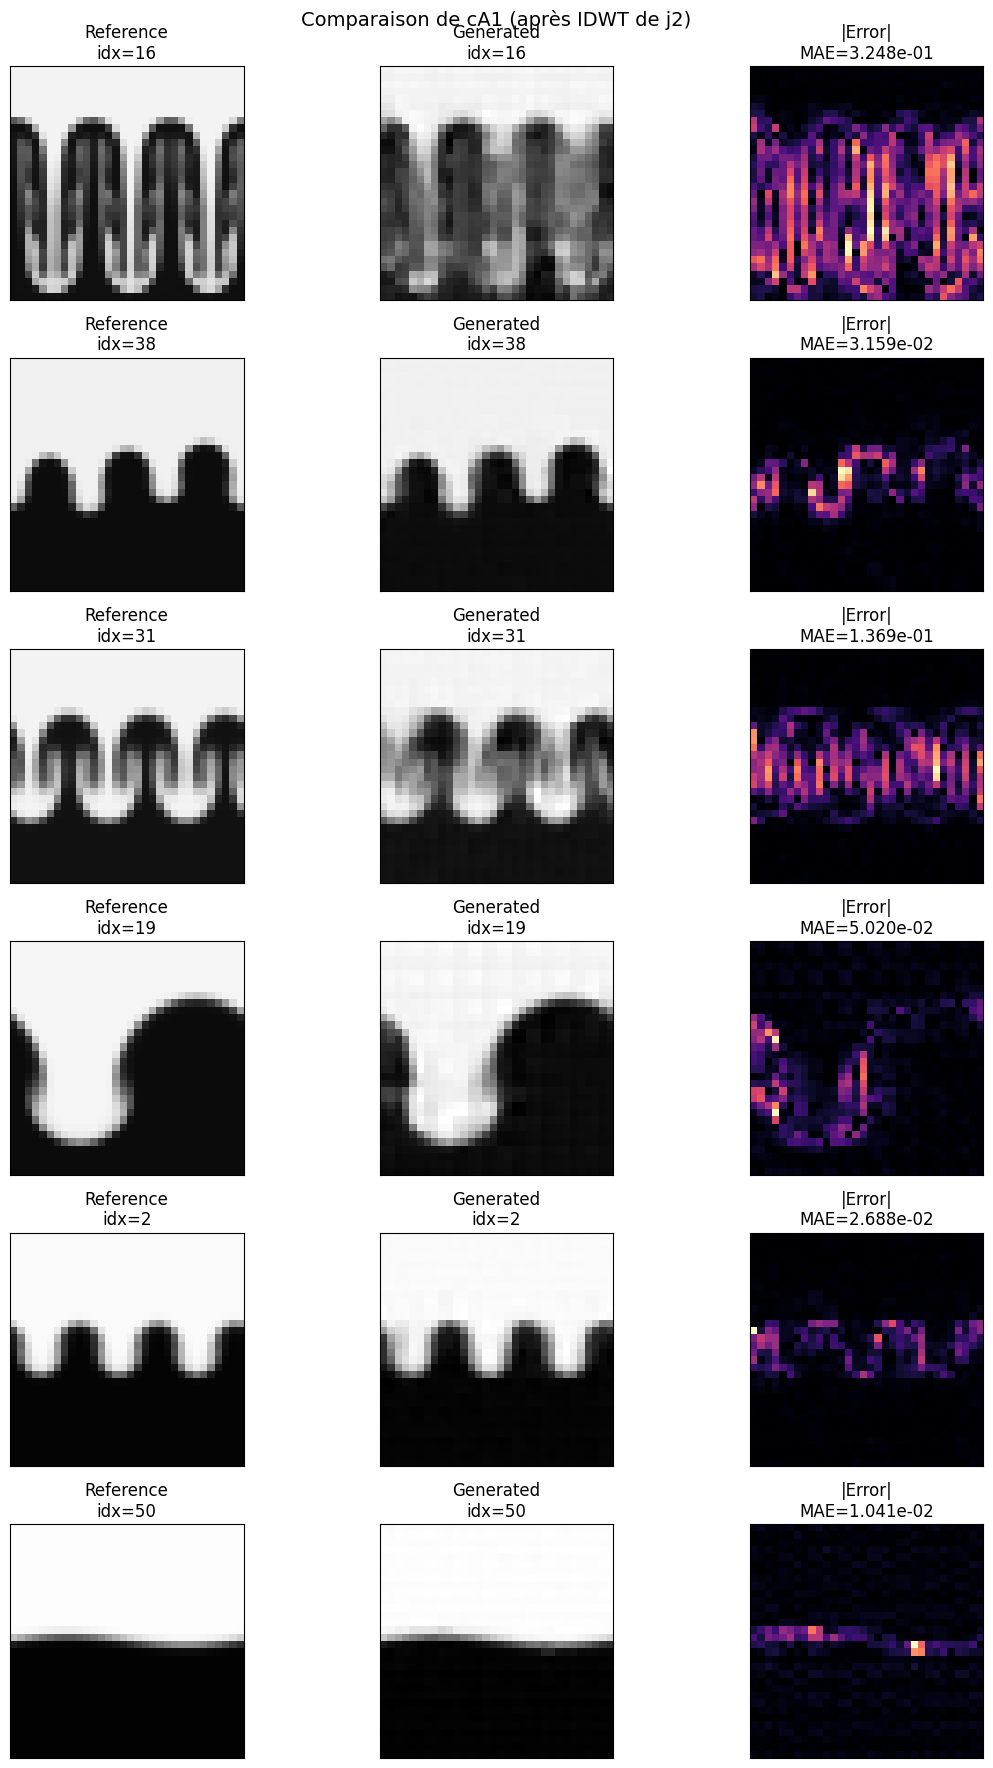

In [12]:
plot_single_channel_comparison(
    real_coeffs[2][:, 0:1],
    reconstructed_ca[2],
    title="Comparaison de cA2 (après IDWT de j3)",
    n_examples=6,
    seed=SEED,
)

plot_single_channel_comparison(
    real_coeffs[1][:, 0:1],
    reconstructed_ca[1],
    title="Comparaison de cA1 (après IDWT de j2)",
    n_examples=6,
    seed=SEED,
)


---
## Comparaison des images finales reconstruites

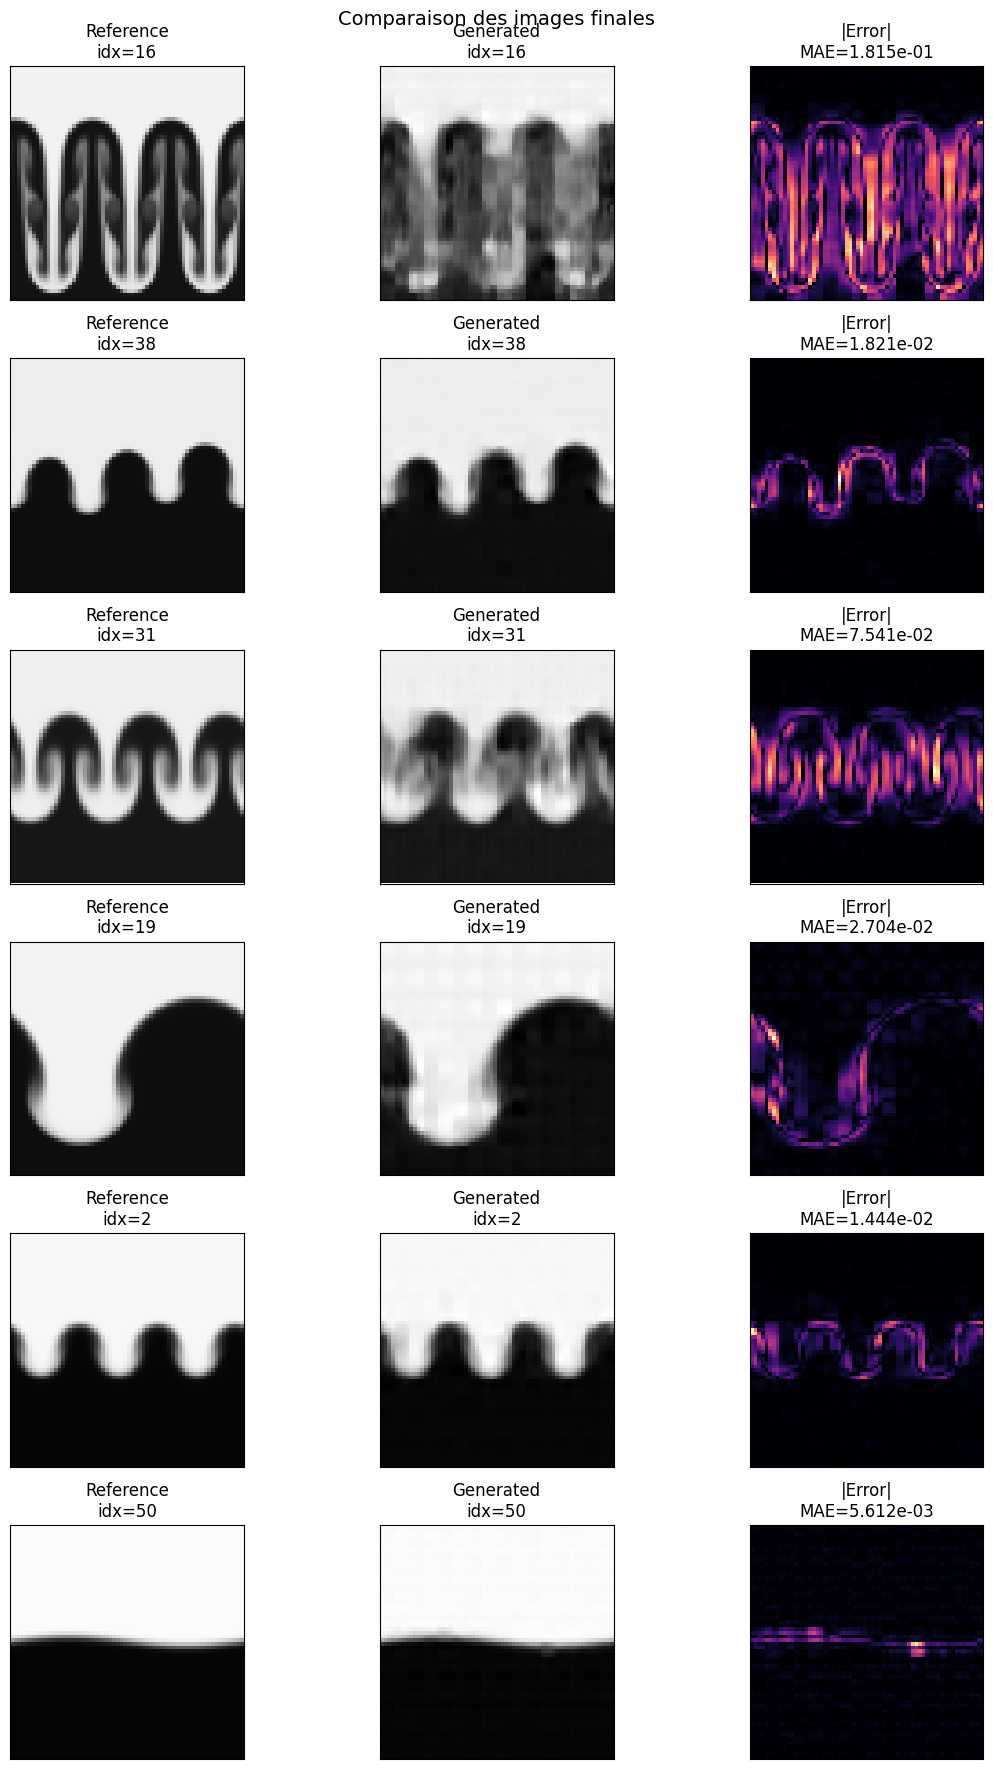

In [13]:
plot_single_channel_comparison(
    final_real_images,
    final_generated_images,
    title="Comparaison des images finales",
    n_examples=6,
    seed=SEED,
)


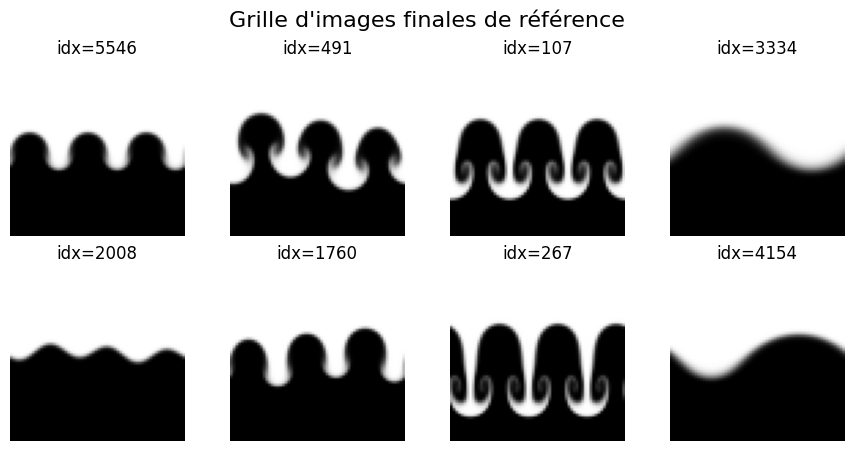

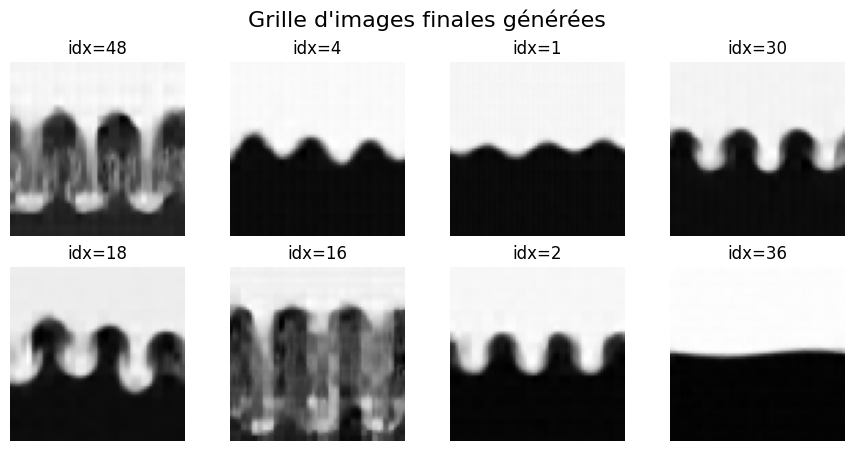

In [14]:
show_grid(final_real_images, n=N_SAMPLES, cols=4, seed=SEED, title="Grille d'images finales de référence")
show_grid(final_generated_images, n=N_SAMPLES, cols=4, seed=SEED, title="Grille d'images finales générées")


---
## FID / PhyFID sur l'image finale uniquement

In [15]:
from lib.PhyFID.metrics import compare_datasets

phyfid_real = to_numpy_images(final_real_images)
phyfid_generated = to_numpy_images(final_generated_images)

print("Images PhyFID (final only):", phyfid_real.shape, phyfid_generated.shape)

PHYFID_N_IMAGES = min(1000, len(phyfid_real) // 2, len(phyfid_generated))
if PHYFID_N_IMAGES == 0:
    raise ValueError("Pas assez d'images pour calculer le FID / PhyFID.")

phyfid_reference = phyfid_real[:PHYFID_N_IMAGES]
phyfid_datasets = {
    "val vs val": phyfid_real[PHYFID_N_IMAGES:2 * PHYFID_N_IMAGES],
    "val vs generated final": phyfid_generated[:PHYFID_N_IMAGES],
}

phyfid_scores = {
    name: compare_datasets(
        phyfid_reference,
        dataset,
        PHYFID_ENCODER,
        batch_size=PHYFID_BATCH_SIZE,
    )
    for name, dataset in phyfid_datasets.items()
}

print(f"Comparaison PhyFID sur {PHYFID_N_IMAGES} images finales")
for name, score in phyfid_scores.items():
    print(f"{name:<24} {score:>10.4f}")


Images PhyFID (final only): (6528, 64, 64) (64, 64, 64)
Comparaison PhyFID sur 64 images finales
val vs val                   0.3204
val vs generated final       3.2374
